In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, Sampler
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
import numpy as np
import re, gc, os

torch.cuda.empty_cache()
gc.collect()
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

GPU: 0.00 GB


In [2]:
# Fix Seed 
import random, os

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seed fixed: {seed}")

SEED = 42
set_seed(SEED)

Seed fixed: 42


## Load Data

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/nhhongg/tbd-origin/train.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/nhhongg/tbd-origin/test.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/nhhongg/tbd-origin/dev.csv")

print(f"Train: {len(train_df)}, Test: {len(test_df)}, Val: {len(val_df)}")
print("\nTrain distribution:")
print(train_df["label"].value_counts())
print("\nTest distribution:")
print(test_df["label"].value_counts())
print("\nVal distribution:")
print(val_df["label"].value_counts())

Train: 4032, Test: 1427, Val: 629

Train distribution:
label
VAGUE           2012
BEFORE           808
AFTER            674
IS_INCLUDED      273
INCLUDES         206
SIMULTANEOUS      59
Name: count, dtype: int64

Test distribution:
label
VAGUE           638
BEFORE          384
AFTER           274
INCLUDES         56
IS_INCLUDED      53
SIMULTANEOUS     22
Name: count, dtype: int64

Val distribution:
label
VAGUE           254
AFTER           172
BEFORE          156
IS_INCLUDED      21
INCLUDES         14
SIMULTANEOUS     12
Name: count, dtype: int64


In [4]:
# Lọc VAGUE trên tập test
test_df  = test_df [test_df ["label"] != "VAGUE"].reset_index(drop=True)

In [5]:
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("\nTrain label distribution:")
print(train_df["label"].value_counts())
print("\nVal label distribution:")
print(val_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train: 4032, Val: 629, Test: 789

Train label distribution:
label
VAGUE           2012
BEFORE           808
AFTER            674
IS_INCLUDED      273
INCLUDES         206
SIMULTANEOUS      59
Name: count, dtype: int64

Val label distribution:
label
VAGUE           254
AFTER           172
BEFORE          156
IS_INCLUDED      21
INCLUDES         14
SIMULTANEOUS     12
Name: count, dtype: int64

Test label distribution:
label
BEFORE          384
AFTER           274
INCLUDES         56
IS_INCLUDED      53
SIMULTANEOUS     22
Name: count, dtype: int64


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   entity1_id     4032 non-null   object
 1   entity2_id     4032 non-null   object
 2   entity1_start  4032 non-null   int64 
 3   entity2_start  4032 non-null   int64 
 4   entity1_end    4032 non-null   int64 
 5   entity2_end    4032 non-null   int64 
 6   entity1_text   4032 non-null   object
 7   entity2_text   4032 non-null   object
 8   document_id    4032 non-null   object
 9   text           4032 non-null   object
 10  label          4032 non-null   object
dtypes: int64(4), object(7)
memory usage: 346.6+ KB


In [7]:
train_df.head(5)

,entity1_id,entity2_id,entity1_start,entity2_start,entity1_end,entity2_end,entity1_text,entity2_text,document_id,text,label
0,e1,e86,108,122,117,128,predicted,demise,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",BEFORE
1,e1,e2,108,159,117,164,predicted,tried,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",VAGUE
2,e1,e4,108,168,117,174,predicted,hasten,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",VAGUE
3,e86,e2,122,159,128,164,demise,tried,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",AFTER
4,e86,e4,122,168,128,174,demise,hasten,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",VAGUE


In [8]:
def insert_tags_fast(text_chunk, s1, e1, s2, e2):
    insertions = [(s1, "<e1>"), (e1, "</e1>"), (s2, "<e2>"), (e2, "</e2>")]
    insertions.sort(key=lambda x: x[0], reverse=True)
    text_list = list(text_chunk)
    for pos, tag in insertions:
        if pos == -1:
            continue
        pos = max(0, min(len(text_list), pos))
        text_list.insert(pos, tag)
    return "".join(text_list)


def find_boundary(text, idx, direction="left"):
    limit = 50
    if direction == "left":
        start = max(0, idx - limit)
        sub = text[start:idx]
        matches = list(re.finditer(r"[\s\.]", sub))
        return start + matches[-1].end() if matches else idx
    else:
        end = min(len(text), idx + limit)
        sub = text[idx:end]
        matches = list(re.finditer(r"[\s\.]", sub))
        return idx + matches[0].start() if matches else idx


def create_chunk(full_text, s1, e1, s2, e2, max_len=256):
    span_start = min(s1, s2)
    span_end   = max(e1, e2)
    dist       = span_end - span_start
    max_char_len = (max_len - 10) * 3

    if dist > max_char_len:
        pad = 50
        c1_s = max(0, s1 - pad); c1_e = min(len(full_text), e1 + pad)
        c2_s = max(0, s2 - pad); c2_e = min(len(full_text), e2 + pad)
        chunk1 = insert_tags_fast(full_text[c1_s:c1_e], s1-c1_s, e1-c1_s, -1, -1)
        chunk2 = insert_tags_fast(full_text[c2_s:c2_e], -1, -1, s2-c2_s, e2-c2_s)
        return chunk1 + " [SEP] " + chunk2

    remaining_chars = max_char_len - dist
    padding     = int(remaining_chars / 2)
    raw_start   = max(0, span_start - padding)
    raw_end     = min(len(full_text), span_end + padding)
    final_start = find_boundary(full_text, raw_start, "left")
    final_end   = find_boundary(full_text, raw_end,   "right")
    chunk_text  = full_text[final_start:final_end]
    return insert_tags_fast(
        chunk_text,
        s1 - final_start, e1 - final_start,
        s2 - final_start, e2 - final_start,
    )


def run_preprocessing(df, max_len=256):
    tqdm.pandas(desc="Processing")
    df["processed_text"] = df.progress_apply(
        lambda row: create_chunk(
            row["text"],
            row["entity1_start"], row["entity1_end"],
            row["entity2_start"], row["entity2_end"],
            max_len=max_len,
        ),
        axis=1,
    )
    return df

print("Preprocessing Train...")
train_df = run_preprocessing(train_df)
print("Preprocessing Val...")
val_df   = run_preprocessing(val_df)
print("Preprocessing Test...")
test_df  = run_preprocessing(test_df)

Preprocessing Train...


Processing: 100%|██████████| 4032/4032 [00:00<00:00, 29737.21it/s]


Preprocessing Val...


Processing: 100%|██████████| 629/629 [00:00<00:00, 29071.26it/s]


Preprocessing Test...


Processing: 100%|██████████| 789/789 [00:00<00:00, 29373.49it/s]


## Dataset

In [9]:
class TBDDataset(Dataset):
    LABEL_MAP = {
        "BEFORE":       0,
        "AFTER":        1,
        "INCLUDES":     2,
        "IS_INCLUDED":  3,
        "SIMULTANEOUS": 4,
        "VAGUE":        5,
    }

    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        encoded = self.tokenizer(
            row["processed_text"],
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        input_ids      = encoded["input_ids"].flatten()
        attention_mask = encoded["attention_mask"].flatten()
        token_type_ids = encoded.get(
            "token_type_ids", torch.zeros_like(input_ids)
        ).flatten()

        e1_id = self.tokenizer.convert_tokens_to_ids("<e1>")
        e2_id = self.tokenizer.convert_tokens_to_ids("<e2>")

        def find_pos(ids, target_id):
            matches = (ids == target_id).nonzero(as_tuple=False)
            if len(matches) > 0:
                return torch.clamp(matches[0][0], 0, self.max_length - 1)
            return torch.tensor(0)

        e1_pos = find_pos(input_ids, e1_id)
        e2_pos = find_pos(input_ids, e2_id)

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "labels":         torch.tensor(self.LABEL_MAP.get(row["label"], -1), dtype=torch.long),
            "e1_pos":         e1_pos,
            "e2_pos":         e2_pos,
            "event1_id":      f"{row['document_id']}_{row['entity1_id']}",
            "event2_id":      f"{row['document_id']}_{row['entity2_id']}",
            "document_id":    row["document_id"],
        }


import numpy as np
from torch.utils.data import Sampler

class SmartBatchSampler(Sampler):
    """
    Gom các cặp trong cùng document vào cùng batch.
    """
    def __init__(self, dataframe, batch_size):
        self.batch_size  = batch_size
        self.doc_groups  = {}
        
        # Gom index theo từng document_id
        for idx, row in dataframe.iterrows():
            self.doc_groups.setdefault(row["document_id"], []).append(idx)
            
        self.doc_ids = list(self.doc_groups.keys())

    def __iter__(self):
        # Xáo trộn thứ tự các Document (Rất cần thiết để mô hình không học vẹt)
        np.random.shuffle(self.doc_ids)
        
        batch = []
        for doc_id in self.doc_ids:
            # Lấy danh sách index của Document hiện tại (GIỮ NGUYÊN THỨ TỰ GỐC)
            idxs = list(self.doc_groups[doc_id])
            
            batch.extend(idxs)
            
            # Cắt thành từng batch đủ kích thước
            while len(batch) >= self.batch_size:
                yield batch[: self.batch_size]
                batch = batch[self.batch_size :]
                
        # Trả về phần dư (nếu có) ở cuối cùng
        if batch:
            yield batch

    def __len__(self):
        total = sum(len(v) for v in self.doc_groups.values())
        return (total + self.batch_size - 1) // self.batch_size


def collate_fn(batch):
    return {
        "input_ids":      torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "token_type_ids": torch.stack([x["token_type_ids"] for x in batch]),
        "labels":         torch.stack([x["labels"]         for x in batch]),
        "e1_pos":         torch.stack([x["e1_pos"]         for x in batch]),
        "e2_pos":         torch.stack([x["e2_pos"]         for x in batch]),
        "event1_id":      [x["event1_id"]   for x in batch],
        "event2_id":      [x["event2_id"]   for x in batch],
        "document_id":    [x["document_id"] for x in batch],
    }


# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenizer.add_special_tokens(
    {"additional_special_tokens": ["<e1>", "</e1>", "<e2>", "</e2>"]}
)


# Dùng trực tiếp train/val/test đã có sẵn
BATCH_SIZE = 32

train_dataset = TBDDataset(train_df, tokenizer)
val_dataset   = TBDDataset(val_df,   tokenizer)
test_dataset  = TBDDataset(test_df,  tokenizer)

train_sampler = SmartBatchSampler(train_df, BATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 126 batches | Val: 20 batches


## Model

In [10]:
class GeoTREModel(nn.Module):
    def __init__(self, model_name="bert-base-uncased", num_classes=6,
                 hidden=256, dropout=0.1, topk=5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        self.topk    = topk

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=8,
            dropout=dropout, batch_first=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.geo_head = nn.Sequential(
            nn.Linear(hidden_size, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

        # Semantic classification head
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

        # Phân biệt vague 
        self.vague_head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),  # 0=non-VAGUE, 1=VAGUE
        )

        # Tolerance cho SIMULTANEOUS
        self.simul_threshold = nn.Parameter(torch.tensor(-2.0))
        # Temperature cho geo logits
        self.geo_temp = nn.Parameter(torch.tensor(0.0))

    def _event_repr(self, hidden_states, pos_idx, attention_mask=None):
        B = hidden_states.size(0)
        h = hidden_states[torch.arange(B), pos_idx]
        query = h.unsqueeze(1)
        key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        _, attn_weights = self.cross_attn(
            query=query, key=hidden_states, value=hidden_states,
            key_padding_mask=key_padding_mask,
        )
        weights = attn_weights.squeeze(1)
        topk_weights, topk_idx = weights.topk(self.topk, dim=-1)
        topk_weights = topk_weights / (topk_weights.sum(dim=-1, keepdim=True) + 1e-9)
        topk_vectors = hidden_states[
            torch.arange(B).unsqueeze(1).expand_as(topk_idx), topk_idx
        ]
        h_context = (topk_weights.unsqueeze(-1) * topk_vectors).sum(dim=1)
        h_rich = self.proj(torch.cat([h, h_context], dim=-1))
        out = self.geo_head(h_rich)
        s = out[:, 0]
        #  min duration 0.05 
        e = s + F.softplus(out[:, 1]) + 0.05
        return s, e, h_rich

    def _compute_geo_logits(self, s1, e1, s2, e2):
        """
        Tính logits hình học dựa trên Allen's Interval Algebra.
        
        Cho 2 event trên trục thời gian:
            E1 = [s1, e1]    E2 = [s2, e2]
        
        5 quan hệ:
            BEFORE:       E1 kết thúc trước khi E2 bắt đầu
            AFTER:        E2 kết thúc trước khi E1 bắt đầu
            INCLUDES:     E1 chứa hẳn E2 (s1 < s2 AND e2 < e1)
            IS_INCLUDED:  E2 chứa hẳn E1 (s2 < s1 AND e1 < e2)
            SIMULTANEOUS: E1 ≈ E2 (gần trùng nhau)
        """
        # ── Khoảng cách giữa 2 cặp biên ──
        d_start = s2 - s1    # > 0 nếu E1 bắt đầu trước E2
        d_end   = e1 - e2    # > 0 nếu E1 kết thúc sau E2
    
        # Ngưỡng tolerance cho mỗi đầu (learnable)
        tol = F.softplus(self.simul_threshold)
    
        # BEFORE: cần gap thực sự giữa e1 và s2 
        # logit > 0 khi s2 > e1 (E1 kết thúc trước E2 bắt đầu)
        logit_before = s2 - e1
    
        # AFTER: đối xứng BEFORE 
        # logit > 0 khi s1 > e2 (E2 kết thúc trước E1 bắt đầu)
        logit_after = s1 - e2
    
        # INCLUDES: E1 chứa E2 
        # Cần ĐỒNG THỜI: d_start > tol (E1 bắt đầu sớm hơn)
        #                 d_end > tol   (E1 kết thúc muộn hơn)
        # min đảm bảo: chỉ dương khi CẢ HAI thỏa mãn
        logit_includes = torch.minimum(d_start, d_end) - tol
    
        # IS_INCLUDED: E2 chứa E1 (đối xứng INCLUDES) 
        # Cần ĐỒNG THỜI: -d_start > tol (E2 bắt đầu sớm hơn)
        #                 -d_end > tol   (E2 kết thúc muộn hơn)
        logit_is_included = torch.minimum(-d_start, -d_end) - tol
    
        # SIMULTANEOUS: E1 ≈ E2
        # dist = tổng lệch ở CẢ HAI đầu
        # 2*tol = tổng ngưỡng (mỗi đầu được lệch tối đa tol)
        dist = torch.abs(d_start) + torch.abs(d_end)
        logit_simultaneous = 2 * tol - dist
    
        # Stack và scale bằng temperature
        logits = torch.stack([
            logit_before,
            logit_after,
            logit_includes,
            logit_is_included,
            logit_simultaneous,
        ], dim=1)
    
        temp = F.softplus(self.geo_temp) + 0.1
        return logits / temp

    def forward(self, input_ids, attention_mask, e1_pos, e2_pos, token_type_ids=None):
        H = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).last_hidden_state

        s1, e1, h1 = self._event_repr(H, e1_pos, attention_mask)
        s2, e2, h2 = self._event_repr(H, e2_pos, attention_mask)

        logits_sem   = self.cls_head(torch.cat([h1, h2], dim=1))
        logits_geo   = self._compute_geo_logits(s1, e1, s2, e2)
        logits_vague = self.vague_head(torch.cat([h1, h2], dim=1)) 

        return s1, e1, s2, e2, logits_sem, logits_geo, logits_vague

## Loss

In [11]:
class TBDLoss(nn.Module):
    """
    total = CE(sem)                           (semantic classification)
          + λ_gce   * CE(geo)                (Allen's geometry → coordinate learning)
          + λ_con   * consistency_loss        (same event = same coordinates)
          + λ_align * KL_sym(sem, geo)        (two branches agree)
    """

    def __init__(self,  lambda_con=0.1,
                 lambda_gce=0.5, lambda_align=0.1, lambda_vague=0.1):
        super().__init__()
        self.register_buffer(
            "class_weights",
            torch.tensor([1.0, 1.2, 3.92, 2.96, 5.0, 0.1])
        )
        self.lambda_con   = lambda_con
        self.lambda_gce   = lambda_gce
        self.lambda_align = lambda_align
        self.lambda_vague = lambda_vague
        print(f"[TBDLoss] CE_sem + {lambda_con}*con "
              f"+ {lambda_gce}*CE_geo + {lambda_align}*KL_align")

    def _consistency_loss(self, s1, e1, s2, e2, event1_ids, event2_ids):
        event_s = {}; event_e = {}
        for i in range(len(s1)):
            event_s.setdefault(event1_ids[i], []).append(s1[i])
            event_s.setdefault(event2_ids[i], []).append(s2[i])
            event_e.setdefault(event1_ids[i], []).append(e1[i])
            event_e.setdefault(event2_ids[i], []).append(e2[i])
        c_losses = []
        for eid in event_s:
            if len(event_s[eid]) < 2: continue
            s_t = torch.stack(event_s[eid]); e_t = torch.stack(event_e[eid])
            c_losses.append(((s_t - s_t.mean().detach())**2).mean() +
                            ((e_t - e_t.mean().detach())**2).mean())
        if not c_losses:
            return torch.tensor(0.0, device=s1.device)
        return torch.stack(c_losses).mean()

    def _vague_separation_loss(self, logits_vague, labels):
        """Binary loss: phân biệt VAGUE (1) vs non-VAGUE (0)"""
        binary_labels = (labels == VAGUE_IDX).long()
        return F.cross_entropy(logits_vague, binary_labels)

    def _alignment_loss(self, logits_sem, logits_geo, eps=1e-8):
        """
        Symmetric KL giữa 2 predicted distributions.
        """
        p_sem = F.softmax(logits_sem[:, :5], dim=-1).clamp(min=eps)  # ← chỉ lấy 5 class
        p_geo = F.softmax(logits_geo,        dim=-1).clamp(min=eps)
        
        kl_fwd = (p_sem * (p_sem.log() - p_geo.log())).sum(-1).mean()
        kl_bwd = (p_geo * (p_geo.log() - p_sem.log())).sum(-1).mean()

        return 0.5 * (kl_fwd + kl_bwd)

    def forward(self, s1, e1, s2, e2, labels, logits_sem, logits_geo=None, logits_vague=None,
                event1_ids=None, event2_ids=None):

        w = self.class_weights.to(logits_sem.device)
        
        # Branch semantic
        ce_sem = F.cross_entropy(logits_sem, labels, weight=w)

        # Consistency
        con_loss = self._consistency_loss(s1, e1, s2, e2, event1_ids, event2_ids) \
                   if (self.lambda_con != 0 and event1_ids is not None) \
                   else torch.tensor(0.0, device=s1.device)

        # Branch geometric CE + Alignment
        ce_geo    = torch.tensor(0.0, device=logits_sem.device)
        aln_loss  = torch.tensor(0.0, device=logits_sem.device)

        if logits_geo is not None:
            ce_geo = F.cross_entropy(logits_geo, labels, weight=w[:5], ignore_index=VAGUE_IDX)
            aln_loss = self._alignment_loss(logits_sem, logits_geo)

        vague_loss = self._vague_separation_loss(logits_vague, labels) \
                 if logits_vague is not None \
                 else torch.tensor(0.0, device=logits_sem.device)

        total = (ce_sem
                 + self.lambda_con   * con_loss
                 + self.lambda_gce   * ce_geo
                 + self.lambda_align * aln_loss
                 + self.lambda_vague * vague_loss)

        return total, ce_sem, con_loss, ce_geo, aln_loss, vague_loss

## Training & Evaluation helpers

In [12]:
LABEL_NAMES  = ["BEFORE", "AFTER", "INCLUDES", "IS_INCLUDED", "SIMULTANEOUS", "VAGUE"]
NUM_CLASSES  = 6
VAGUE_IDX    = 5                        # index của VAGUE để mask khi tính F1
EVAL_LABELS  = list(range(5))  

def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    model.train()
    total = ce_sum = con_sum = gce_sum = aln_sum = vag_sum = 0.0 

    bar = tqdm(loader, desc="  Train")
    for batch in bar:
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)
        ev1_ids        = batch["event1_id"]
        ev2_ids        = batch["event2_id"]

        optimizer.zero_grad()
        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )

        loss, ce, con, gce, aln, vag = criterion(
            s1, e1, s2, e2, labels,
            logits_sem, logits_geo, logits_vague, 
            ev1_ids, ev2_ids
        )
        if loss.dim() > 0: loss = loss.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()

        total   += loss.item()
        ce_sum  += ce.item()
        con_sum += con.item()
        gce_sum += gce.item()
        aln_sum += aln.item()
        vag_sum += vag.item()  # ← thêm

        bar.set_postfix(loss=f"{loss.item():.3f}", ce=f"{ce.item():.3f}",
                    gce=f"{gce.item():.3f}", vag=f"{vag.item():.3f}")

    n = len(loader)
    return total/n, ce_sum/n, con_sum/n, gce_sum/n, aln_sum/n, vag_sum/n 

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Val  "):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        loss, ce, con, gce, aln, vag = criterion(
            s1, e1, s2, e2, labels, logits_sem, logits_geo, logits_vague
        )
        if loss.dim() > 0: loss = loss.mean()
        total += loss.item()

        # Quyết định cuối dùng logits_sem (branch chính)
        preds = logits_sem.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    mask = np.array(all_labels) != VAGUE_IDX
    f1   = f1_score(np.array(all_labels)[mask], np.array(all_preds)[mask],
                    labels=EVAL_LABELS,
                    average="macro", zero_division=0)
    return avg_loss, acc, f1

## Khởi tạo model, optimizer, criterion

In [13]:
if "model"     in dir(): del model
if "optimizer" in dir(): del optimizer
if "criterion" in dir(): del criterion
gc.collect(); torch.cuda.empty_cache()

# Cấu hình
EPOCHS      = 40
LR          = 2e-5
PATIENCE    = 5
SAVE_PATH   = "/kaggle/working/model_final_tbd_no_align_loss_seed_42.pth"
LAMBDA_CON   = 0.1
LAMBDA_GCE   = 0.5
LAMBDA_ALIGN = 0
LAMBDA_VAGUE = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GeoTREModel(model_name="bert-base-uncased", num_classes=NUM_CLASSES)
model.encoder.resize_token_embeddings(len(tokenizer))

if torch.cuda.device_count() > 1:
    print(f"--> {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

criterion = TBDLoss(
    lambda_con=LAMBDA_CON,
    lambda_gce=LAMBDA_GCE,
    lambda_align=LAMBDA_ALIGN,
    lambda_vague=LAMBDA_VAGUE,
)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

from transformers import get_linear_schedule_with_warmup
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


--> 2 GPUs
[TBDLoss] CE_sem + 0.1*con + 0.5*CE_geo + 0*KL_align
Total steps: 5040 | Warmup steps: 504


## Training loop

In [14]:
best_f1           = 0.0
loss_patience_cnt = 0
prev_train_loss   = float("inf")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_ce, tr_con, tr_gce, tr_aln, tr_vag = train_epoch(  
        model, train_loader, criterion, optimizer, device, scheduler
    )

    val_loss, val_acc, val_f1 = eval_epoch(
        model, val_loader, criterion, device
    )

    print(f"  Train: total={tr_loss:.4f}  ce={tr_ce:.4f}  "
          f"con={tr_con:.4f}  "
          f"gce={tr_gce:.4f}  aln={tr_aln:.4f}  vag={tr_vag:.4f}")  
    print(f"  Val  : loss={val_loss:.4f}  acc={val_acc:.4f}  macro-F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        core = model.module if isinstance(model, nn.DataParallel) else model
        torch.save(core.state_dict(), SAVE_PATH)
        print(f"  --> Saved! (best F1={best_f1:.4f})")

    if (prev_train_loss - tr_loss) < 0.005:
        loss_patience_cnt += 1
        print(f"   Patience {loss_patience_cnt}/{PATIENCE}")
        if loss_patience_cnt >= PATIENCE:
            print("Early stopping!")
            break
    else:
        loss_patience_cnt = 0

    prev_train_loss = tr_loss

print(f"\nBest Val Macro-F1: {best_f1:.4f}")


Epoch 1/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  3.02it/s]


  Train: total=2.7111  ce=1.7705  con=0.0917  gce=1.7232  aln=0.1076  vag=0.6975
  Val  : loss=2.6147  acc=0.2051  macro-F1=0.1808
  --> Saved! (best F1=0.1808)

Epoch 2/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  2.96it/s]


  Train: total=2.5204  ce=1.6887  con=0.0832  gce=1.5070  aln=0.1816  vag=0.6982
  Val  : loss=2.4884  acc=0.2067  macro-F1=0.2134
  --> Saved! (best F1=0.2134)

Epoch 3/40


...

  Train: total=0.0615  ce=0.0036  con=0.1385  gce=0.0861  aln=0.2578  vag=0.0101
  Val  : loss=5.5172  acc=0.5374  macro-F1=0.4002
   Patience 3/5

Epoch 35/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  2.96it/s]


  Train: total=0.0603  ce=0.0029  con=0.1375  gce=0.0861  aln=0.2545  vag=0.0069
  Val  : loss=5.8151  acc=0.5231  macro-F1=0.3734
   Patience 4/5

Epoch 36/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  2.89it/s]

  Train: total=0.0618  ce=0.0028  con=0.1344  gce=0.0893  aln=0.2620  vag=0.0092
  Val  : loss=5.7899  acc=0.5246  macro-F1=0.3627
   Patience 5/5
Early stopping!

Best Val Macro-F1: 0.5268


## GRID SEARCH ALPHA TRÊN VAL SET 

In [15]:
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(SAVE_PATH))
model.to(device)
model.eval()

all_logits_sem_val, all_logits_geo_val, all_labels_val = [], [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Val for alpha search"):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        all_logits_sem_val.append(logits_sem.cpu())
        all_logits_geo_val.append(logits_geo.cpu())
        all_labels_val.extend(labels.cpu().numpy())

prob_sem_val   = F.softmax(torch.cat(all_logits_sem_val), dim=-1)
prob_geo_val   = F.softmax(torch.cat(all_logits_geo_val), dim=-1)
all_labels_val = np.array(all_labels_val)

prob_geo_val_pad = F.pad(prob_geo_val, (0, 1), value=0.0)

best_alpha, best_f1_val = 0.0, 0.0
for alpha in np.arange(0.0, 1.05, 0.05):
    prob_combined = alpha * prob_sem_val + (1 - alpha) * prob_geo_val_pad
    preds    = prob_combined.argmax(dim=-1).numpy()
    mask_val = all_labels_val != VAGUE_IDX
    f1_val   = f1_score(all_labels_val[mask_val], preds[mask_val],
                        labels=EVAL_LABELS, average="macro", zero_division=0)
    if f1_val > best_f1_val:
        best_f1_val = f1_val
        best_alpha  = alpha

print(f"Best alpha (val): {best_alpha:.2f} | Val Macro-F1: {best_f1_val:.4f}")

Val for alpha search: 100%|██████████| 20/20 [00:06<00:00,  2.96it/s]

Best alpha (val): 0.70 | Val Macro-F1: 0.5583


## Evaluate on Test set

Testing: 100%|██████████| 25/25 [00:08<00:00,  2.95it/s]


Dùng alpha từ val set: 0.70

  1. SEMANTIC Branch
  Micro-F1: 0.8010  |  Macro-F1: 0.5619
              precision    recall  f1-score   support

      BEFORE     0.8886    0.8516    0.8697       384
       AFTER     0.7760    0.8978    0.8325       274
    INCLUDES     0.5833    0.5000    0.5385        56
 IS_INCLUDED     0.5536    0.5849    0.5688        53
SIMULTANEOUS     0.0000    0.0000    0.0000        22

    accuracy                         0.8010       789
   macro avg     0.5603    0.5669    0.5619       789
weighted avg     0.7806    0.8010    0.7888       789


  2. GEOMETRIC Branch
  Micro-F1: 0.7845  |  Macro-F1: 0.5970
              precision    recall  f1-score   support

      BEFORE     0.9088    0.8307    0.8680       384
       AFTER     0.8664    0.8285    0.8470       274
    INCLUDES     0.4844    0.5536    0.5167        56
 IS_INCLUDED     0.5139    0.6981    0.5920        53
SIMULTANEOUS     0.1250    0.2273    0.1613        22

    accuracy                    

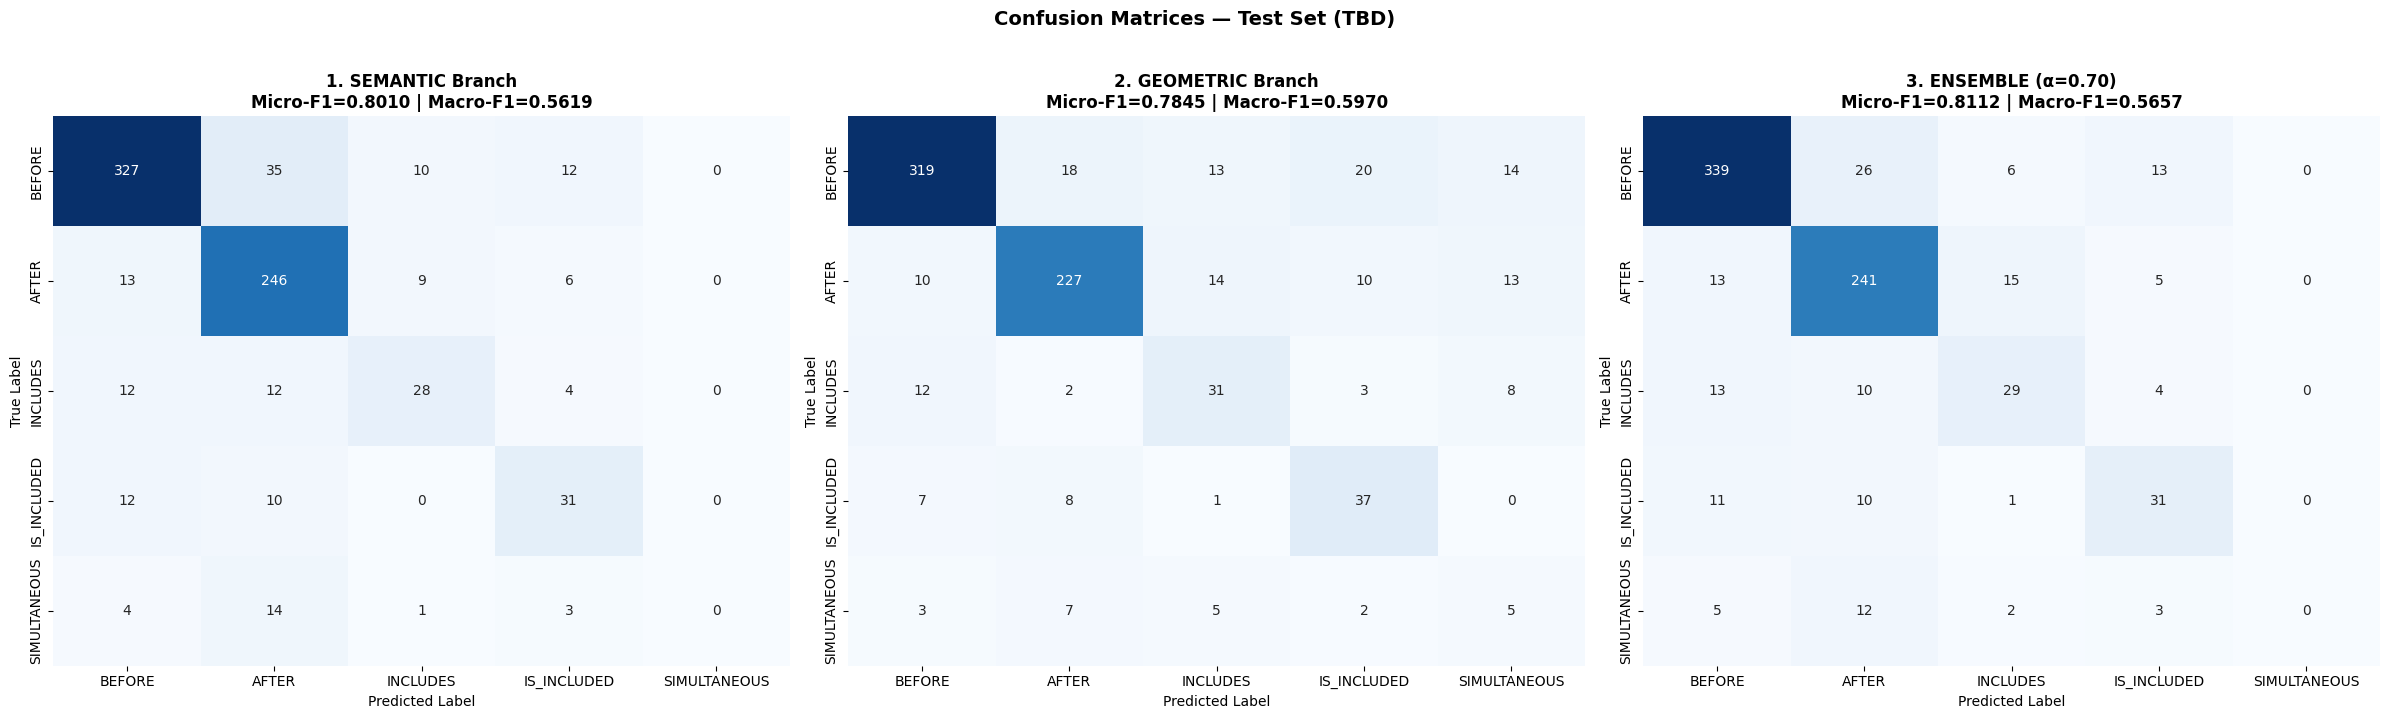


  SUMMARY — TEST SET
  Strategy                            |   Micro-F1 |   Macro-F1
  ------------------------------------+------------+-----------
  1. SEMANTIC Branch                  |     0.8010 |     0.5619
  2. GEOMETRIC Branch                 |     0.7845 |     0.5970
  3. ENSEMBLE (α=0.70)                |     0.8112 |     0.5657


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

# Load best model 
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(SAVE_PATH))
model.to(device)
model.eval()

# Collect tất cả logits
all_logits_sem = []
all_logits_geo = []
all_labels     = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        all_logits_sem.append(logits_sem.cpu())
        all_logits_geo.append(logits_geo.cpu())
        all_labels.extend(labels.cpu().numpy())

all_logits_sem = torch.cat(all_logits_sem, dim=0)
all_logits_geo = torch.cat(all_logits_geo, dim=0)
all_labels     = np.array(all_labels)

prob_sem = F.softmax(all_logits_sem, dim=-1)
prob_geo = F.softmax(all_logits_geo, dim=-1)

print(f"Dùng alpha từ val set: {best_alpha:.2f}")

# TÍNH PREDICTIONS CHO CẢ 3 NHÁNH
preds_sem  = all_logits_sem.argmax(dim=-1).numpy()
preds_geo  = all_logits_geo.argmax(dim=-1).numpy()
prob_geo_pad = F.pad(prob_geo, (0, 1), value=0.0)
prob_best = best_alpha * prob_sem + (1 - best_alpha) * prob_geo_pad
preds_ens  = prob_best.argmax(dim=-1).numpy()

strategies = [
    ("1. SEMANTIC Branch",                preds_sem),
    ("2. GEOMETRIC Branch",               preds_geo),
    (f"3. ENSEMBLE (α={best_alpha:.2f})", preds_ens),
]

# CLASSIFICATION REPORT 
for title, preds in strategies:
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"  Micro-F1: {micro_f1:.4f}  |  Macro-F1: {macro_f1:.4f}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels, preds,
        target_names=LABEL_NAMES[:5],
        labels=EVAL_LABELS,
        zero_division=0, digits=4,
    ))

# CONFUSION MATRIX 
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (title, preds) in zip(axes, strategies):
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)

    cm = confusion_matrix(all_labels, preds, labels=EVAL_LABELS)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABEL_NAMES[:5], yticklabels=LABEL_NAMES[:5],
        ax=ax, cbar=False,
    )
    ax.set_title(f"{title}\nMicro-F1={micro_f1:.4f} | Macro-F1={macro_f1:.4f}",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices — Test Set (TBD)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# BẢNG TỔNG KẾT
print("\n" + "="*60)
print("  SUMMARY — TEST SET")
print("="*60)
print(f"  {'Strategy':<35} | {'Micro-F1':>10} | {'Macro-F1':>10}")
print(f"  {'-'*35}-+-{'-'*10}-+-{'-'*10}")

for title, preds in strategies:
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)
    print(f"  {title:<35} | {micro_f1:>10.4f} | {macro_f1:>10.4f}")

print("="*60)